# Experiment 2 — Carrabin: Intertrial Variability
Response distribution comparison between human data and models,
using Wasserstein distance as the metric for intertrial variability.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
from itertools import combinations
import sys

sys.path.insert(0, str(Path("..").resolve()))
from statannotations.Annotator import Annotator
from utils.paths import data_path, RUNS_DIR
from utils.plot_style import apply_style


In [2]:
apply_style()
palette = sns.color_palette("colorblind")

# model display order and colors
MODELS = ["Human", "Bayes", "RL", "NoisyCounting"]
PALETTE = {
    "Human": "black",
    "Bayes": palette[0],
    "RL": palette[1],
    "NoisyCounting": palette[2],
}

# run folders — all wasserstein fits stored in runs/wasserstein
WASSERSTEIN_RUN = "wasserstein"  # update if named differently

# Sample participant selection — override automatically selected pids here
# Set to None to use automatic percentile-based selection
SAMPLE_PIDS = {
    "narrow": None,  # e.g. 15
    "medium": None,  # e.g. 7
    "broad": None,  # e.g. 4
}

# Narrow / medium / broad: linestyle, color (all model panels), legend text
SAMPLE_STYLES = ["-", "--", ":"]
SAMPLE_COLORS = [palette[0], palette[1], palette[2]]
SAMPLE_LABELS = ["Narrow", "Medium", "Broad"]


In [3]:
human = pd.read_pickle(data_path("carrabin.pkl"))

responses = {"Human": human}
run_dir = RUNS_DIR / WASSERSTEIN_RUN
for model in MODELS:
    if model == "Human":
        continue
    path = run_dir / f"{model}_carrabin_responses.pkl"
    if path.exists():
        responses[model] = pd.read_pickle(path)
    else:
        print(f"Warning: missing {path}")
        responses[model] = pd.DataFrame()

for name, df in responses.items():
    if df is None or len(df) == 0:
        print(f"{name}: (no data)")
        continue
    pids = sorted(df["pid"].unique())
    print(f"{name}: n_responses={len(df)}, n_participants={len(pids)}")
    preview = pids[:12]
    suf = " ..." if len(pids) > len(preview) else ""
    print(f"  pids ({len(pids)}): {preview}{suf}")


Human: n_responses=20755, n_participants=21
  pids (21): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] ...
Bayes: n_responses=20755, n_participants=21
  pids (21): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] ...
RL: n_responses=20755, n_participants=21
  pids (21): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] ...
NoisyCounting: n_responses=20755, n_participants=21
  pids (21): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] ...


In [4]:
std_by_pid = human.groupby("pid")["response"].std()
sorted_std = std_by_pid.dropna().sort_values()
n_p = len(sorted_std)
third = n_p // 3
tercile = pd.Series(index=sorted_std.index, dtype=object)
for i, pid in enumerate(sorted_std.index):
    if i < third:
        tercile.loc[pid] = "narrow"
    elif i < 2 * third:
        tercile.loc[pid] = "medium"
    else:
        tercile.loc[pid] = "broad"

print("Participants sorted by response std (tercile by count, low→high):")
summary = pd.DataFrame(
    {
        "pid": sorted_std.index.astype(int),
        "std": sorted_std.values,
        "tercile": [tercile.loc[p] for p in sorted_std.index],
    }
)
print(summary.to_string(index=False))

vals = sorted_std.to_numpy(dtype=float)
p10, p50, p90 = np.percentile(vals, [10, 50, 90])


def nearest_pid(target: float) -> int:
    diff = (std_by_pid - target).abs()
    return int(diff.idxmin())


auto_narrow = nearest_pid(p10)
auto_medium = nearest_pid(p50)
auto_broad = nearest_pid(p90)

if all(v is None for v in SAMPLE_PIDS.values()):
    sample_pids = [auto_narrow, auto_medium, auto_broad]
else:
    sample_pids = []
    for key, auto in zip(
        ["narrow", "medium", "broad"], [auto_narrow, auto_medium, auto_broad]
    ):
        v = SAMPLE_PIDS[key]
        sample_pids.append(int(v) if v is not None else auto)

print("\nSelected sample pids [narrow, medium, broad]:")
for lab, pid in zip(SAMPLE_LABELS, sample_pids):
    if pid not in std_by_pid.index:
        raise ValueError(f"{lab}: pid {pid} not found in human data")
    print(f"  {lab}: pid={pid}, std={float(std_by_pid.loc[pid]):.6f}")


Participants sorted by response std (tercile by count, low→high):
 pid      std tercile
  20 0.255735  narrow
  10 0.270760  narrow
  15 0.314440  narrow
   7 0.320896  narrow
   1 0.326536  narrow
   3 0.344832  narrow
  14 0.349517  narrow
  17 0.354421  medium
   5 0.371263  medium
  11 0.387872  medium
  21 0.394870  medium
  18 0.401813  medium
  12 0.432613  medium
  16 0.435355  medium
  19 0.462613   broad
   9 0.472133   broad
   2 0.482684   broad
  13 0.487990   broad
   8 0.550135   broad
   6 0.585928   broad
   4 0.637406   broad

Selected sample pids [narrow, medium, broad]:
  Narrow: pid=15, std=0.314440
  Medium: pid=21, std=0.394870
  Broad: pid=8, std=0.550135


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Bayes vs. RL: Wilcoxon test (paired samples), P_val:9.537e-07 Stat=0.000e+00
RL vs. NoisyCounting: Wilcoxon test (paired samples), P_val:1.907e-06 Stat=1.000e+00
Bayes vs. NoisyCounting: Wilcoxon test (paired samples), P_val:9.537e-07 Stat=0.000e+00


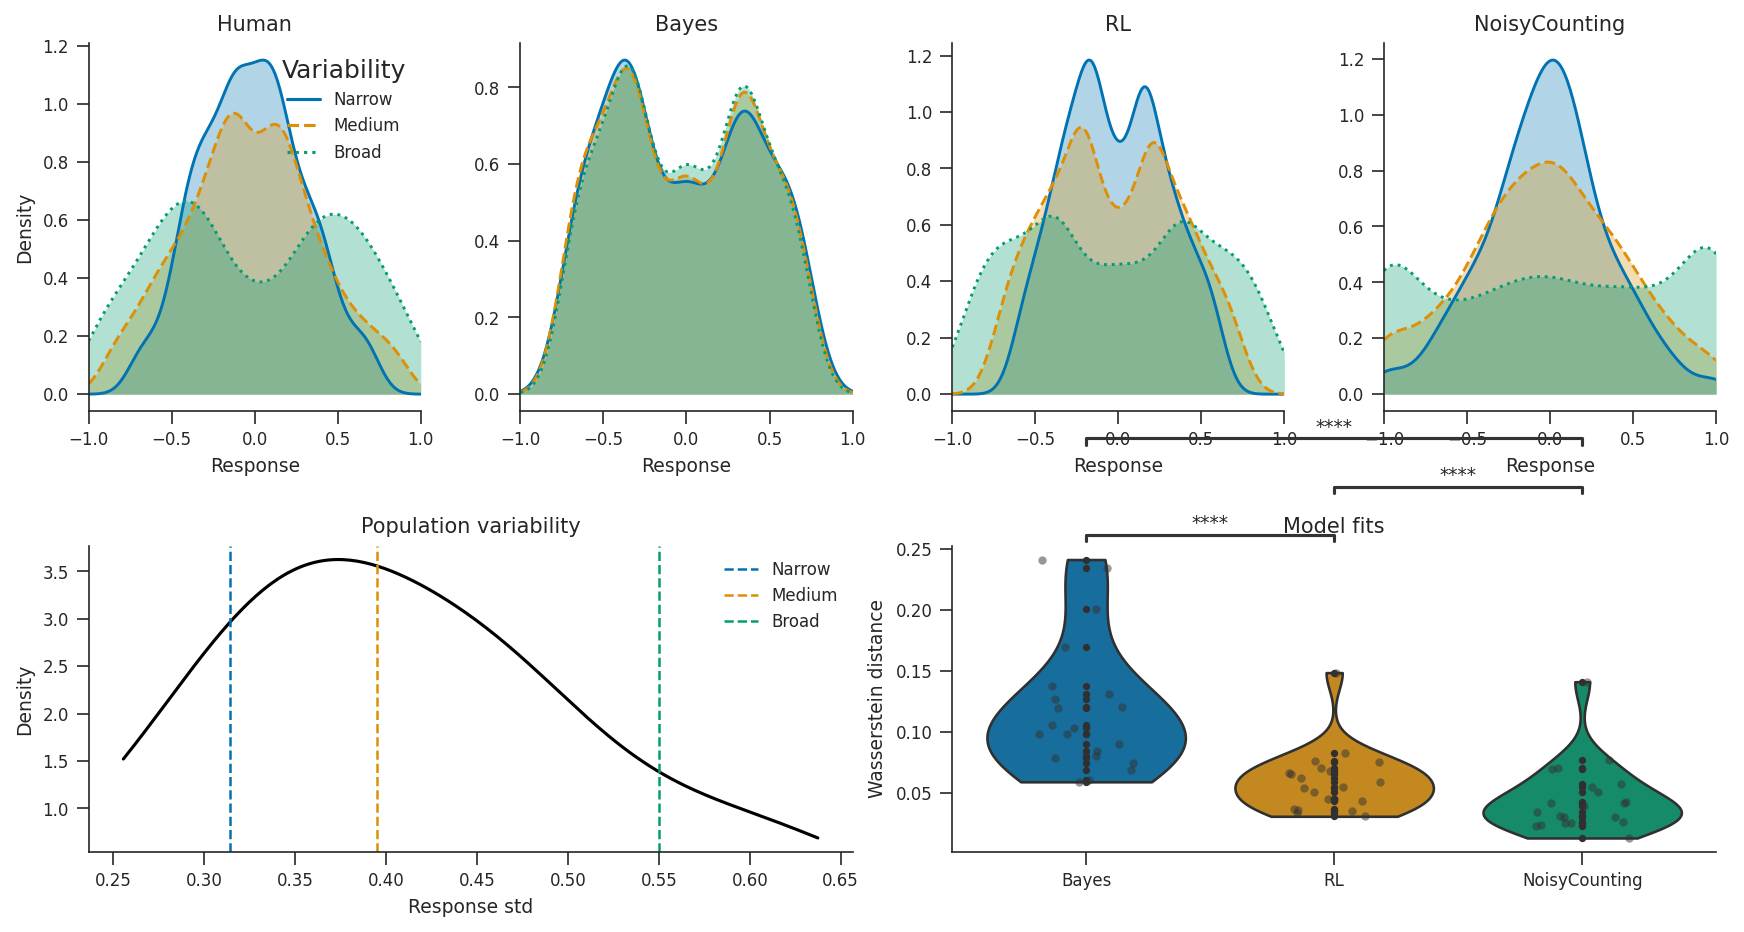

In [5]:
from matplotlib.lines import Line2D


def kde_y(values: np.ndarray, xgrid: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 2:
        return np.zeros_like(xgrid, dtype=float)
    kde = gaussian_kde(values)
    return kde(xgrid)


x_kde = np.linspace(-1.0, 1.0, 400)

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(
    2, 4, height_ratios=[1.2, 1], hspace=0.4, wspace=0.3
)

ax_row1 = [fig.add_subplot(gs[0, i]) for i in range(4)]
ax_var = fig.add_subplot(gs[1, 0:2])
ax_wass = fig.add_subplot(gs[1, 2:4])

for ax, model_name in zip(ax_row1, MODELS):
    df = responses.get(model_name)
    if df is None or len(df) == 0:
        ax.set_title(model_name)
        ax.set_xlim(-1, 1)
        ax.set_xlabel("Response")
        ax.set_ylabel("Density" if ax is ax_row1[0] else "")
        continue
    for pid, sty, pcol in zip(sample_pids, SAMPLE_STYLES, SAMPLE_COLORS):
        sub = df.loc[df["pid"] == pid, "response"].dropna().to_numpy()
        y = kde_y(sub, x_kde)
        ax.fill_between(x_kde, y, alpha=0.3, color=pcol, linewidth=0)
        ax.plot(x_kde, y, color=pcol, linestyle=sty, linewidth=1.4)
    ax.set_title(model_name)
    ax.set_xlabel("Response")
    ax.set_xlim(-1, 1)
    if ax is ax_row1[0]:
        ax.set_ylabel("Density")
        handles = [
            Line2D([0], [0], color=c, linestyle=s, label=lab)
            for c, s, lab in zip(SAMPLE_COLORS, SAMPLE_STYLES, SAMPLE_LABELS)
        ]
        ax.legend(handles=handles, frameon=False, title="Variability")
    else:
        ax.set_ylabel("")

sns.kdeplot(x=std_by_pid.dropna(), color="black", ax=ax_var, cut=0)
for pid, col, lab in zip(sample_pids, SAMPLE_COLORS, SAMPLE_LABELS):
    xv = float(std_by_pid.loc[pid])
    ax_var.axvline(
        xv, color=col, linestyle="--", linewidth=1.2, label=lab
    )
ax_var.set_xlabel("Response std")
ax_var.set_ylabel("Density")
ax_var.set_title("Population variability")
ax_var.legend(frameon=False, loc="best")

order = ["Bayes", "RL", "NoisyCounting"]
perf_parts = []
for model in order:
    p = run_dir / f"{model}_carrabin_performance.pkl"
    if p.exists():
        perf_parts.append(pd.read_pickle(p))
    else:
        print(f"Warning: missing performance {p}")

if perf_parts:
    wass_perf = pd.concat(perf_parts, ignore_index=True)
    plot_palette = {k: PALETTE[k] for k in order}
    sns.violinplot(
        data=wass_perf,
        x="model_type",
        y="cv_loss_mean",
        order=order,
        hue="model_type",
        palette=plot_palette,
        inner="point",
        cut=0,
        legend=False,
        ax=ax_wass,
    )
    np.random.seed(42)
    sns.stripplot(
        data=wass_perf,
        x="model_type",
        y="cv_loss_mean",
        order=order,
        color="0.2",
        alpha=0.5,
        jitter=0.2,
        size=4,
        ax=ax_wass,
    )
    wass_order = ["Bayes", "RL", "NoisyCounting"]
    pairs = list(combinations(wass_order, 2))
    annotator = Annotator(
        ax_wass,
        pairs,
        data=wass_perf,
        x="model_type",
        y="cv_loss_mean",
        order=wass_order,
    )
    annotator.configure(test="Wilcoxon", text_format="star", loc="inside")
    ylim = ax_wass.get_ylim()
    annotator.apply_and_annotate()
    ax_wass.set_ylim(ylim)
else:
    ax_wass.text(
        0.5,
        0.5,
        "No performance data",
        ha="center",
        va="center",
        transform=ax_wass.transAxes,
    )

ax_wass.set_xlabel("")
ax_wass.set_ylabel("Wasserstein distance")
ax_wass.set_title("Model fits")

for ax in fig.axes:
    sns.despine(ax=ax, top=True, right=True)

fig_dir = Path("..").resolve() / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "variability_carrabin.png", dpi=300)
plt.savefig(fig_dir / "variability_carrabin.pdf")
plt.show()


## Notes
- Update WASSERSTEIN_RUN folder name if different from 'wasserstein'
- Sample participants selected at 10th, 50th, 90th percentile of response std
